
--- NGÀY 63: CHẠM VÀO THỊ GIÁC MÁY TÍNH (COMPUTER VISION) ---
Số lượng hình ảnh dùng để huấn luyện: 60000
Kích thước 1 bức ảnh: (28, 28)


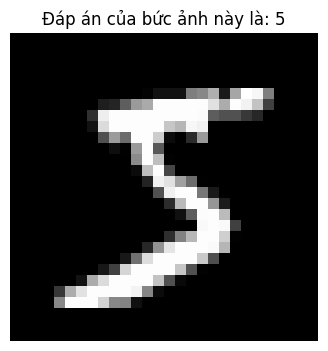


--- ĐÂY LÀ NHỮNG GÌ MÁY TÍNH THỰC SỰ NHÌN THẤY ---
  1 154 253  90   0   0   0   0   0   0 
  0 139 253 190   2   0   0   0   0   0 
  0  11 190 253  70   0   0   0   0   0 
  0   0  35 241 225 160 108   1   0   0 
  0   0   0  81 240 253 253 119  25   0 
  0   0   0   0  45 186 253 253 150  27 
  0   0   0   0   0  16  93 252 253 187 
  0   0   0   0   0   0   0 249 253 249 
  0   0   0   0  46 130 183 253 253 207 
  0   0  39 148 229 253 253 253 250 182 


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("\n--- NGÀY 63: CHẠM VÀO THỊ GIÁC MÁY TÍNH (COMPUTER VISION) ---")

#1. Tải bộ dữ liệu MNIST từ keras
#mnist.load_data() tự chia sẵn bộ train với test
mnist = tf.keras.datasets.mnist
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

print(f"Số lượng hình ảnh dùng để huấn luyện: {len(X_train_img)}")
print(f"Kích thước 1 bức ảnh: {X_train_img[0].shape}")

#2. Bốc ngẫu nhiên bức ảnh đầu tiên ra xem 
anh_dau_tien = X_train_img[0]
nhan_anh_dau_tien = y_train_img[0]

#3. Vẽ bức ảnh đó 
plt.figure(figsize=(4,4))
plt.imshow(anh_dau_tien, cmap='gray')
plt.title(f"Đáp án của bức ảnh này là: {nhan_anh_dau_tien}")
plt.axis('off')
plt.show()

#4.Cách máy tính nhìn
print("\n--- ĐÂY LÀ NHỮNG GÌ MÁY TÍNH THỰC SỰ NHÌN THẤY ---")
#Lấy một góc nhỏ của bức ảnh 10x10 pixel
goc_nho = anh_dau_tien[10:20, 10:20]
for hang in goc_nho:
    for diem_anh in hang:
        print(f"{diem_anh:3}", end=" ")# In mỗi số chiếm 3 khoảng trắng
    print()

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

print("\n--- NGÀY 64: XÂY DỰNG AI ĐỌC CHỮ VIẾT TAY ---")

#1.Tiền xử lí (PREPROCESSING)
#Ép các con số về khoảng 0-1
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

#2. Xây dựng bộ não
model_vision = Sequential()

#Lớp đầu vào nhận bức ảnh 2D 28x28
model_vision.add(Input(shape=(28,28)))

#Lớp ép phảng dữ liệu: kéo dãn dữ liệu 28x28 thành 1 sợi dây dài 784 pixel (vì các nơ-ron chỉ đọc đc mảng 1 chiều)
model_vision.add(Flatten())

#Lớp ẩn: dùng 128 nơ-ron để suy nghĩ
model_vision.add(Dense(128, activation='relu'))

#Lớp đầu ra dùng 10 nơ-ron (tương ứng với các số từ 0-9)
#Hàm 'softmax' giúp chia đều 100% cho 10 nơ-ron
model_vision.add(Dense(10, activation='softmax'))

#3.Biên dịch mô hình 
#Vì nhãn là các số nguyên 0,1,2,...,9 nên phải dùng 'sparse_categorical_crossentropy'
model_vision.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#4.In bản thiết kế
print("\nBẢN THIẾT KẾ BỘ NÃO THỊ GIÁC:")
model_vision.summary()


--- NGÀY 64: XÂY DỰNG AI ĐỌC CHỮ VIẾT TAY ---

BẢN THIẾT KẾ BỘ NÃO THỊ GIÁC:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import time

print("\n--- NGÀY 65: BẮT ĐẦU HUẤN LUYỆN AI ĐỌC CHỮ ---")

start_time = time.time()

# 1. Huấn luyện mô hình (Fit)
# Ép AI học 10 vòng (epochs=10)
# Mỗi lần nhét 32 bức ảnh (batch_size=32)
lich_su_vision = model_vision.fit(
    X_train_img,
    y_train_img,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

end_time = time.time()
print(f"\nThời gian huấn luyện: {round(end_time - start_time, 2)} giây")

# 2. LÀM BÀI THI THẬT SỰ TRÊN TẬP TEST (10.000 bức ảnh AI chưa từng thấy)
print("\n--- BẮT ĐẦU LÀM BÀI THI CHÍNH THỨC ---")
# Hàm .evaluate() giúp tự động đối chiếu X_test_img với y_test_img và trả về điểm số
test_loss, test_acc = model_vision.evaluate(X_test_img, y_test_img, )

print(f"Độ chính xác trên tập Test (Thực tế): {test_acc * 100:.2f}%")



--- NGÀY 65: BẮT ĐẦU HUẤN LUYỆN AI ĐỌC CHỮ ---
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9171 - loss: 0.2912 - val_accuracy: 0.9529 - val_loss: 0.1627
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9634 - loss: 0.1270 - val_accuracy: 0.9663 - val_loss: 0.1138
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9745 - loss: 0.0863 - val_accuracy: 0.9664 - val_loss: 0.1074
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9798 - loss: 0.0659 - val_accuracy: 0.9723 - val_loss: 0.0910
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9850 - loss: 0.0500 - val_accuracy: 0.9721 - val_loss: 0.0914
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0390 - val_accuracy: 0.9764 - val_loss: 0.0843
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0305 - val_accuracy: 0.9744 - val_loss: 0.0915
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 


--- NGÀY 66: ĐỌC SUY NGHĨ CỦA AI ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

[AI đang suy nghĩ ...] Xác suất cho từng con số (0-9):
[0.    0.    0.    0.    0.    0.    0.    0.041 0.    0.959]

=> AI CHỐT ĐÁP ÁN: Đây là số 9 (Độ tự tin: 95.9%)


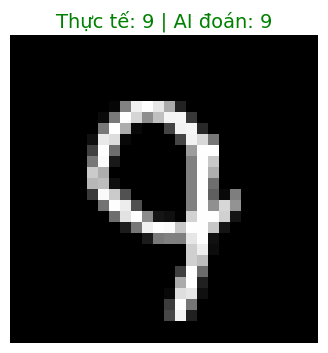

In [14]:
import numpy as np
import matplotlib.pyplot as plt

print("\n--- NGÀY 66: ĐỌC SUY NGHĨ CỦA AI ---")

#1.Bốc bừa 1 bức ảnh
vi_tri = 999
anh_thu = X_test_img[vi_tri]
nhan_thuc_te = y_test_img[vi_tri]

#2.Đưa ảnh cho AI dự đoán
#Lưu ý: AI luôn yêu cầu đầu vào là 1 xấp ảnh
#Dù chỉ có 1 ảnh vẫn phải bọc lại thành 1 xấp (1,28,28) để AI hiểu là nhận vào 1 ảnh cỡ 28x28
anh_dua_vao = anh_thu.reshape(1,28,28)
du_doan = model_vision.predict(anh_dua_vao)

#3. In ra suy nghĩ của AI
print(f"\n[AI đang suy nghĩ ...] Xác suất cho từng con số (0-9):")
xac_suat_10_so = np.round(du_doan[0],3)
print(xac_suat_10_so)

so_ai_chon = np.argmax(du_doan[0])
do_tu_tin = np.max(du_doan[0]) * 100

print(f"\n=> AI CHỐT ĐÁP ÁN: Đây là số {so_ai_chon} (Độ tự tin: {do_tu_tin:.1f}%)")

#5. Vẽ bức ảnh đó ra xem
plt.figure(figsize=(4,4))
plt.imshow(anh_thu, cmap='gray')

mau_chu = 'green' if so_ai_chon == nhan_thuc_te else 'red'
plt.title(f"Thực tế: {nhan_thuc_te} | AI đoán: {so_ai_chon}", color=mau_chu, fontsize=14)
plt.axis('off')
plt.show()

In [17]:
from tensorflow.keras.layers import  Conv2D, MaxPooling2D

print("\n--- NGÀY 67: NÂNG CẤP ĐÔI MẮT VỚI MẠNG TÍCH CHẬP (CNN) ---")

#1.Tiền xử lí cho CNN
#Ép lại hình dáng ảnh từ (28,28) thành (28,28,1) để CNN hiểu là ảnh có 1 kênh màu (grayscale)
X_train_cnn = X_train_img.reshape(-1,28,28,1)
X_test_cnn = X_test_img.reshape(-1,28,28,1)

#2.Xây dựng kiến trúc CNN
model_cnn = Sequential()
model_cnn.add(Input(shape=(28,28,1)))

#Lớp tích chập 1: dùng 32 kính núp cơ 3x3 để quét ảnh
model_cnn.add(Conv2D(32, kernel_size=(3,3), activation='relu'))

#Lớp gộp 1: thu nhỏ ảnh lại 1 nửa (lấy điểm sáng nhất trong ô 2x2)
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

#Lớp tích chập 2: Dùng 64 kính núp để soi sâu hơn vào các chi tiết phức tạp
model_cnn.add(Conv2D(64,kernel_size=(3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

#3.Kết nối với bộ não
model_cnn.add(Flatten()) #ép phẳng dữ liệu
model_cnn.add(Dense(64,activation='relu'))
model_cnn.add(Dense(10,activation='softmax'))

#4.Biên dịch mô hình
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', #dùng khi cần làm việc với các số nguyên (0,1,...,9)
    metrics=['accuracy'] #gọi hàm accuracy
)

# 5. IN BẢN THIẾT KẾ CNN
print("\nBẢN THIẾT KẾ CNN CHUYÊN NGHIỆP:")
model_cnn.summary()


--- NGÀY 67: NÂNG CẤP ĐÔI MẮT VỚI MẠNG TÍCH CHẬP (CNN) ---

BẢN THIẾT KẾ CNN CHUYÊN NGHIỆP:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

DJTMEMAY
